In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd().parent

FEATURES_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "advanced_audio_features.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

print(df.shape)

df.head()

(520, 40)


,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,contrast_6,contrast_7,tonnetz_1,tonnetz_2,tonnetz_3,tonnetz_4,tonnetz_5,tonnetz_6,filename,category
0,-254.93631,85.83962,-107.103160,31.011576,-39.987736,-17.290342,-37.214104,-18.145690,-11.705071,-17.621454,...,20.464414,45.704715,-0.058836,0.004075,0.051868,0.035464,-0.014806,-0.015532,1-100038-A-14.wav,chirping_birds
1,-466.62210,144.26140,22.961350,52.213543,2.970680,11.319603,-2.895933,0.076406,-8.929120,10.019115,...,16.233288,28.473721,0.002136,-0.003342,-0.027320,0.071995,-0.018120,0.001736,1-101296-A-19.wav,thunderstorm
2,-441.77423,153.39592,32.532093,38.864770,0.386356,-1.514098,2.681722,-3.470331,-3.546912,5.873673,...,16.746074,28.574655,-0.005311,0.008006,-0.021965,0.031961,0.004954,0.005678,1-101296-B-19.wav,thunderstorm
3,-173.18240,131.66370,-23.350657,44.626896,-16.704086,34.943077,13.708267,24.017622,-3.575602,12.136042,...,15.456582,42.903741,0.002883,0.021413,-0.012975,-0.041927,0.009535,0.009389,1-103298-A-9.wav,crow
4,-400.28085,155.72517,73.404076,15.198190,5.499929,16.989422,18.179058,7.343544,-0.929693,-1.168286,...,15.181650,16.613661,0.004814,0.000623,-0.009786,0.010140,0.004016,0.000385,1-115521-A-19.wav,thunderstorm


In [3]:
feature_columns = [

    col

    for col in df.columns

    if col not in [
        "filename",
        "category"
    ]
]

X = df[
    feature_columns
]

y = df["category"]

print(X.shape)
print(y.shape)

(520, 38)
(520,)


In [4]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(
    y
)

print(
    encoder.classes_
)

['chirping_birds' 'crackling_fire' 'crickets' 'crow' 'frog' 'insects'
 'pouring_water' 'rain' 'rooster' 'sea_waves' 'thunderstorm' 'water_drops'
 'wind']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(416, 38)
(104, 38)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

print(X_train.shape)

(416, 38)


In [7]:
rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=None,

    random_state=42,

    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [8]:
y_pred = rf_model.predict(
    X_test
)

print(
    y_pred[:20]
)

[ 4  6 12  3 11 10 11  7  8  1 11  9  6  8  8  4 12 10  9  5]


In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.7211538461538461


In [10]:
print(

    classification_report(

        y_test,

        y_pred,

        target_names=
        encoder.classes_
    )
)

                precision    recall  f1-score   support

chirping_birds       0.57      0.50      0.53         8
crackling_fire       0.58      0.88      0.70         8
      crickets       0.80      0.50      0.62         8
          crow       0.83      0.62      0.71         8
          frog       0.75      0.75      0.75         8
       insects       0.80      0.50      0.62         8
 pouring_water       0.88      0.88      0.88         8
          rain       0.83      0.62      0.71         8
       rooster       0.88      0.88      0.88         8
     sea_waves       0.70      0.88      0.78         8
  thunderstorm       0.57      1.00      0.73         8
   water_drops       0.70      0.88      0.78         8
          wind       0.80      0.50      0.62         8

      accuracy                           0.72       104
     macro avg       0.75      0.72      0.71       104
  weighted avg       0.75      0.72      0.71       104



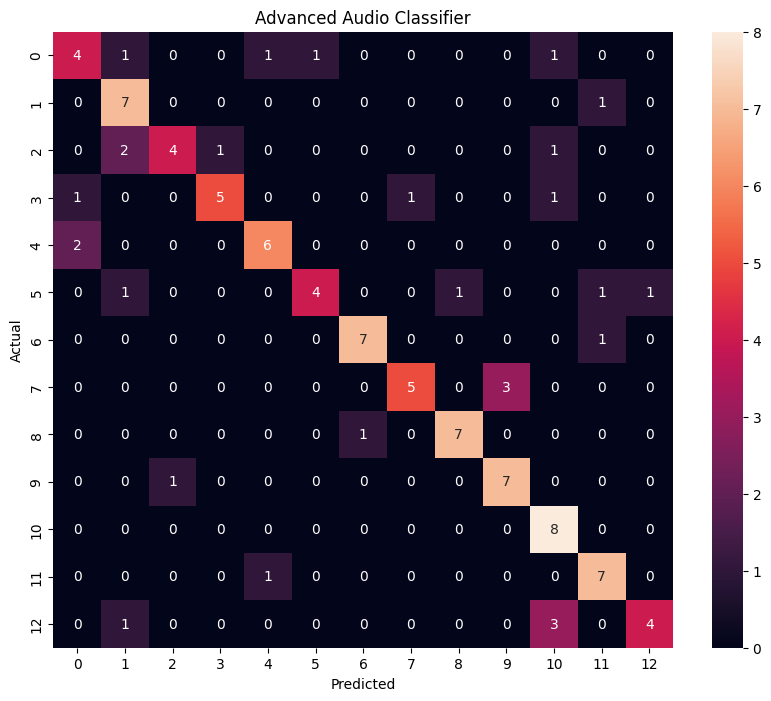

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Advanced Audio Classifier"
)

plt.show()

In [12]:
importance_df = pd.DataFrame({

    "Feature":
    feature_columns,

    "Importance":
    rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,mfcc_2,0.066096
2,mfcc_3,0.053163
0,mfcc_1,0.048276
27,contrast_3,0.043714
29,contrast_5,0.042531
31,contrast_7,0.041617
30,contrast_6,0.040096
3,mfcc_4,0.036579
28,contrast_4,0.033881
4,mfcc_5,0.029789
